# When There Is No Solution: The Pseudo-Inverse

**This notebook is self-contained; it recaps the inverse briefly before generalizing it.**
*Optional / stretch material — the payoff returns in Unit 3's regression notebooks.*

Every system so far had an answer. Real data doesn't work that way: with more measurements than unknowns, no line passes through every point, $A$ isn't even square, and $A^{-1}$ doesn't exist. The **pseudo-inverse** is what you use instead — and it turns out to be exactly the machinery behind fitting a line to data, which is where Unit 3 picks up.

## Learning objectives

- Recognize an **overdetermined** system and why it has no exact solution.
- Use the pseudo-inverse $A^{+}$ to get the best approximate solution.
- Connect $\hat{\boldsymbol\beta} = X^{+}\mathbf{y}$ to fitting a line through a cloud of points.

## Background

A system $A\mathbf{x} = \mathbf{b}$ with more equations than unknowns — $A$ **tall** — is called **overdetermined**. Generally no $\mathbf{x}$ satisfies all the equations at once, so instead we ask for the $\mathbf{x}$ that comes *closest*: the one minimizing the length of the error,

$$\lVert A\mathbf{x} - \mathbf{b}\rVert.$$

That best $\mathbf{x}$ is given by the **Moore–Penrose pseudo-inverse**

$$A^{+} = (A^{\top}A)^{-1}A^{\top}, \qquad \mathbf{x} = A^{+}\mathbf{b},$$

which are the **normal equations**. Note $A^{\top}A$ *is* square, so it can have an ordinary inverse even when $A$ cannot. When $A$ happens to be square and invertible, $A^{+}$ reduces to $A^{-1}$ — the pseudo-inverse is a genuine generalization.

## This notebook covers

1. Three points, two unknowns: no line fits exactly.
2. $A^{+}$ and the best-fit answer; the residuals it minimizes.
3. Why "least squares" is the right name.
4. The same computation on real data — a preview of §3.7.

**Prerequisites:** `U2-5_Determinants-2_InverseAsUndo`

**Dataset:** `Real Estate Data.csv` (Ames housing), from the shared dataset library via `helpers.data(...)`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
# plotting helper: label the axis ends compactly (for grids of small panels)
def label_axes(ax, x='x', y='y', size=8):
    ax.set_xlabel(x, loc='right', fontsize=size)
    ax.set_ylabel(y, loc='top', rotation=0, fontsize=size)

## 1. Three points, two unknowns

Fit a straight line $y = m x + c$ through three points that are **not** collinear: $(1, 2)$, $(2, 3)$, and $(3, 5)$. Each point gives one equation in the two unknowns $m$ and $c$:

$$\begin{bmatrix}1 & 1\\ 2 & 1\\ 3 & 1\end{bmatrix}\begin{bmatrix}m\\ c\end{bmatrix} = \begin{bmatrix}2\\ 3\\ 5\end{bmatrix}$$

Three equations, two unknowns — one more constraint than we have freedom. No line passes through all three points, so this system has **no exact solution**. $A$ is $3\times2$: not square, so $A^{-1}$ is not even defined.

In [2]:
pts_x = np.array([1.0, 2.0, 3.0])
pts_y = np.array([2.0, 3.0, 5.0])

A = np.column_stack([pts_x, np.ones(3)])     # each row: [x, 1], for  y = m*x + c
b = pts_y

helpers.show(A, name="A")
helpers.show(b, name=r"\mathbf{b}")
print("A is", A.shape, "- tall, not square, so there is no A inverse")

try:
    np.linalg.inv(A)
except np.linalg.LinAlgError as e:
    print("np.linalg.inv(A) raises LinAlgError:", e)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

A is (3, 2) - tall, not square, so there is no A inverse
np.linalg.inv(A) raises LinAlgError: Last 2 dimensions of the array must be square


## 2. The pseudo-inverse

Build $A^{+} = (A^{\top}A)^{-1}A^{\top}$ by hand. The trick is that $A^{\top}A$ is $2\times2$ — square, and here invertible — even though $A$ itself is $3\times2$.

In [3]:
AtA = A.T @ A
helpers.show(AtA, name=r"A^\top A")
print(f"det(A^T A) = {np.linalg.det(AtA):.1f}  -> invertible")

A_plus = np.linalg.inv(AtA) @ A.T
helpers.show(np.round(A_plus, 3), name="A^{+}")
helpers.show(np.round(np.linalg.pinv(A), 3), label="numpy's pinv, for comparison")

<IPython.core.display.Math object>

det(A^T A) = 6.0  -> invertible


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
solution = A_plus @ b
m, c = solution
helpers.show(np.round(solution, 3), label="best fit [m, c]")
print(f"best-fit line:  y = {m:.2f} x + {c:.2f}")

residuals = A @ solution - b
helpers.show(np.round(residuals, 3), label="residuals  Ax - b")
print(f"total squared error = {np.sum(residuals**2):.4f}  (not zero: no line fits exactly)")

<IPython.core.display.Math object>

best-fit line:  y = 1.50 x + 0.33


<IPython.core.display.Math object>

total squared error = 0.1667  (not zero: no line fits exactly)


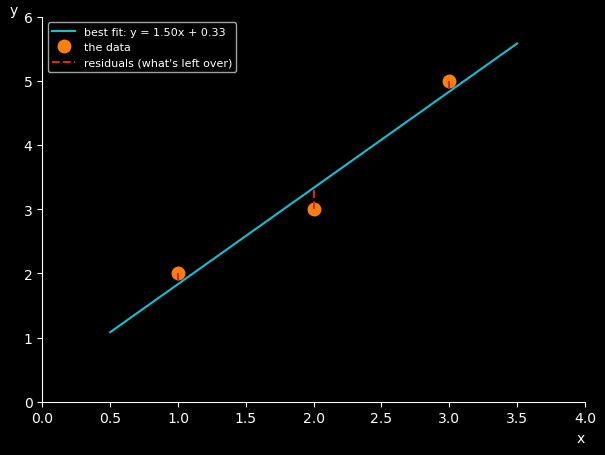

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
grid = np.linspace(0.5, 3.5, 100)
ax.plot(grid, m * grid + c, color="tab:cyan", label=f"best fit: y = {m:.2f}x + {c:.2f}")
ax.plot(pts_x, pts_y, "o", color="tab:orange", markersize=9, label="the data")

for xi, yi in zip(pts_x, pts_y):
    ax.plot([xi, xi], [yi, m * xi + c], "--", color="tab:red", lw=1.5)
ax.plot([], [], "--", color="tab:red", label="residuals (what's left over)")

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_xlim(0, 4); ax.set_ylim(0, 6)
ax.legend(loc="upper left", fontsize=8)
plt.show()

## 3. Why "least squares"

The pseudo-inverse doesn't pick just any nearby answer — it picks the one making the **sum of the squared residuals** as small as possible. To see that isn't a claim to take on faith, we try a grid of nearby lines and check that none beats it.

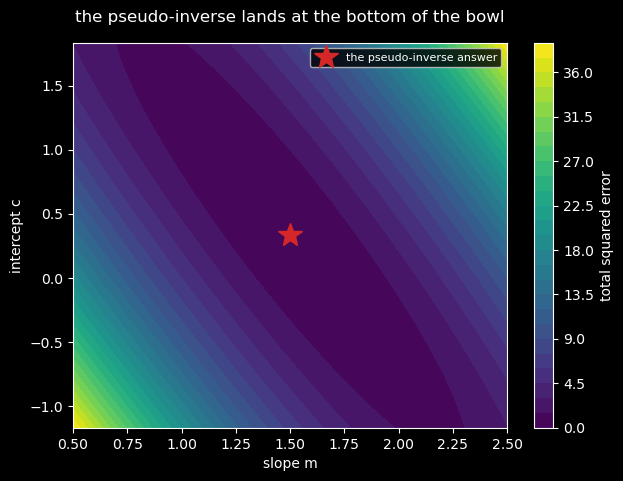

best error found on the grid : 0.16686
error at the pinv answer     : 0.16667


In [6]:
# score a grid of candidate lines by total squared error
ms = np.linspace(m - 1, m + 1, 120)
cs = np.linspace(c - 1.5, c + 1.5, 120)
MM, CC = np.meshgrid(ms, cs)
err = np.zeros_like(MM)
for i in range(MM.shape[0]):
    for j in range(MM.shape[1]):
        err[i, j] = np.sum((MM[i, j] * pts_x + CC[i, j] - pts_y) ** 2)

fig, ax = plt.subplots(figsize=(7, 5))
cs_plot = ax.contourf(MM, CC, err, levels=30, cmap="viridis")
ax.plot(m, c, "*", color="tab:red", markersize=18, label="the pseudo-inverse answer")
fig.colorbar(cs_plot, ax=ax, label="total squared error")
ax.set_xlabel("slope m")
ax.set_ylabel("intercept c")
ax.set_title("the pseudo-inverse lands at the bottom of the bowl", pad=15)
ax.legend(fontsize=8)
plt.show()

print(f"best error found on the grid : {err.min():.5f}")
print(f"error at the pinv answer     : {np.sum(residuals**2):.5f}")

The star sits at the bottom of the bowl. Nothing on the grid does better, which is what "least squares" means — and it is why this one formula underlies essentially all of linear regression.

## 4. The same thing, on real data

Nothing above depended on having only three points. Here is the identical computation on every house in a real sales table, predicting sale price from living area. The matrix $A$ now has one row per house — very tall indeed — but $A^{\top}A$ is still just $2\times2$, however many rows you feed it.

This is exactly the calculation §3.7 will call *linear regression*, on the same table.

In [7]:
homes = pd.read_csv(helpers.data('Real Estate/Real Estate Data.csv'), index_col=0)
area = homes['Living Area Above Grade'].values.astype(float)
price = homes['Sale Price'].values.astype(float)
print(f"{len(area)} houses")

X = np.column_stack([area, np.ones(len(area))])       # 1404 x 2
beta = np.linalg.pinv(X) @ price                      # the same A+ b, one line
print(f"X is {X.shape},  X^T X is {(X.T @ X).shape}")
print(f"\nfitted:  price = {beta[0]:.1f} * area + {beta[1]:.0f}")
print(f"so each extra square foot is worth about ${beta[0]:.0f}")

1404 houses
X is (1404, 2),  X^T X is (2, 2)

fitted:  price = 106.7 * area + 20331
so each extra square foot is worth about $107


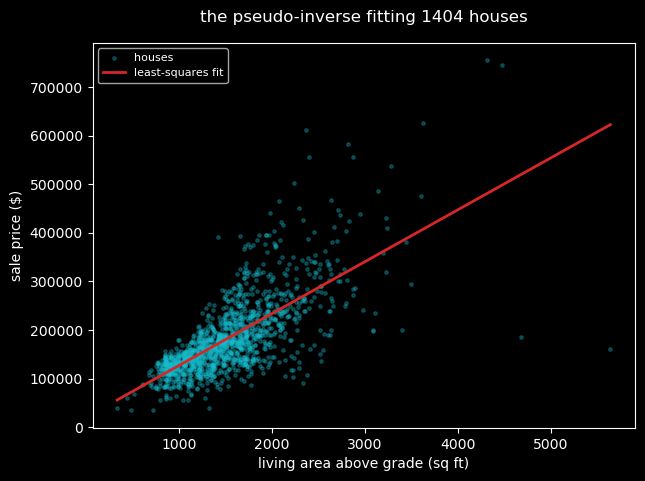

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(area, price, s=6, alpha=0.3, color="tab:cyan", label="houses")
grid = np.linspace(area.min(), area.max(), 100)
ax.plot(grid, beta[0] * grid + beta[1], color="tab:red", lw=2, label="least-squares fit")
ax.set_xlabel("living area above grade (sq ft)")
ax.set_ylabel("sale price ($)")
ax.legend(fontsize=8)
ax.set_title("the pseudo-inverse fitting 1404 houses", pad=15)
plt.show()

## 5. Summary

- An **overdetermined** system (more equations than unknowns) generally has **no exact solution**; a tall $A$ has no inverse.
- The **pseudo-inverse** $A^{+} = (A^{\top}A)^{-1}A^{\top}$ gives the $\mathbf{x}$ minimizing $\lVert A\mathbf{x} - \mathbf{b}\rVert$ — the **normal equations**. $A^{\top}A$ is square even when $A$ isn't.
- It minimizes the **sum of squared residuals**, hence *least squares*.
- The same formula, applied to a data table, **is** linear regression — picked up in §3.7.

Next: the directions a transformation doesn't rotate — eigenvectors (`U2-6_Eigen-1_DirectionsThatDontTurn`).